## DNA Classification Using Hierarchical Clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram # For hierarchical clustering
from sklearn.preprocessing import StandardScaler # For normalizing features
from scipy.cluster.hierarchy import fcluster



# https://www.kaggle.com/datasets/miadul/dna-classification-dataset link of dataset


In [ ]:
dna = pd.read_csv("synthetic_dna_dataset.csv") # reads dataset
print(dna.head())

  Sample_ID                                           Sequence  GC_Content  \
0  SAMPLE_1  CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...        50.0   
1  SAMPLE_2  TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...        45.0   
2  SAMPLE_3  GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...        51.0   
3  SAMPLE_4  ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...        55.0   
4  SAMPLE_5  TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...        46.0   

   AT_Content  Sequence_Length  Num_A  Num_T  Num_C  Num_G  kmer_3_freq  \
0        50.0              100     22     28     19     31        0.986   
1        55.0              100     27     28     22     23        0.486   
2        49.0              100     26     23     30     21        0.367   
3        45.0              100     28     17     23     32        0.404   
4        54.0              100     24     30     25     21        0.818   

   Mutation_Flag Class_Label Disease_Risk  
0              0    Bacteria        

In [ ]:
dna.shape #checks shape

(3000, 13)

In [ ]:
dna.columns #shows all the columns

Index(['Sample_ID', 'Sequence', 'GC_Content', 'AT_Content', 'Sequence_Length',
       'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq', 'Mutation_Flag',
       'Class_Label', 'Disease_Risk'],
      dtype='object')

| Column Name          | Description                                                                     | Data Type        | Example Value                                       | Notes                                              |
| -------------------- | ------------------------------------------------------------------------------- | ---------------- | --------------------------------------------------- | -------------------------------------------------- |
| **Sample\_ID**       | Unique identifier for the DNA sample                                            | String           | `SAMPLE_1`                                          | Always unique                                      |
| **Sequence**         | DNA nucleotide sequence composed of A, T, C, G                                  | String           | `CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...` | In this dataset, length = 100 bases                |
| **GC\_Content**      | Percentage of bases that are G (Guanine) or C (Cytosine) in the sequence        | Float            | `50.0`                                              | Range: 0–100; GC% + AT% = 100%                     |
| **AT\_Content**      | Percentage of bases that are A (Adenine) or T (Thymine) in the sequence         | Float            | `50.0`                                              | Complement of GC\_Content                          |
| **Sequence\_Length** | Total number of nucleotide bases in the sequence                                | Integer          | `100`                                               | Constant length for all samples in this dataset    |
| **Num\_A**           | Count of Adenine (A) bases in the sequence                                      | Integer          | `22`                                                | Sum with Num\_T, Num\_C, Num\_G = Sequence\_Length |
| **Num\_T**           | Count of Thymine (T) bases in the sequence                                      | Integer          | `28`                                                |                                                    |
| **Num\_C**           | Count of Cytosine (C) bases in the sequence                                     | Integer          | `19`                                                |                                                    |
| **Num\_G**           | Count of Guanine (G) bases in the sequence                                      | Integer          | `31`                                                |                                                    |
| **kmer\_3\_freq**    | Normalized frequency of a specific 3-nucleotide pattern (3-mer) in the sequence | Float            | `0.986`                                             | Range: 0–1                                         |
| **Mutation\_Flag**   | Indicator for presence of mutation                                              | Integer (0 or 1) | `0`                                                 | `0` = No mutation, `1` = Mutation present          |
| **Class\_Label**     | Biological class of the DNA sample                                              | String           | `Bacteria`                                          | In dataset: 4 possible classes                     |
| **Disease\_Risk**    | Risk classification based on DNA sequence                                       | String           | `High`                                              | Possible values: `Low`, `Medium`, `High`           |


In [ ]:
dna.describe(include='all') # Display summary statistics

,Sample_ID,Sequence,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,Class_Label,Disease_Risk
count,3000,3000,3000.000000,3000.000000,3000.0,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000
unique,3000,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3
top,SAMPLE_3000,CCGGATGCCGCTCTATACACCGTCATAGCCTGGAACACACAAATAA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bacteria,High
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,761,1046
mean,NaN,NaN,50.120000,49.880000,100.0,24.950667,24.929333,25.004000,25.116000,0.547738,0.496667,NaN,NaN
std,NaN,NaN,5.062688,5.062688,0.0,4.317458,4.317702,4.349056,4.329603,0.258521,0.500072,NaN,NaN
min,NaN,NaN,34.000000,34.000000,100.0,11.000000,9.000000,10.000000,12.000000,0.100000,0.000000,NaN,NaN
25%,NaN,NaN,47.000000,47.000000,100.0,22.000000,22.000000,22.000000,22.000000,0.330000,0.000000,NaN,NaN
50%,NaN,NaN,50.000000,50.000000,100.0,25.000000,25.000000,25.000000,25.000000,0.543000,0.000000,NaN,NaN
75%,NaN,NaN,53.000000,53.000000,100.0,28.000000,28.000000,28.000000,28.000000,0.772250,1.000000,NaN,NaN


In [ ]:
dna.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sample_ID        3000 non-null   object 
 1   Sequence         3000 non-null   object 
 2   GC_Content       3000 non-null   float64
 3   AT_Content       3000 non-null   float64
 4   Sequence_Length  3000 non-null   int64  
 5   Num_A            3000 non-null   int64  
 6   Num_T            3000 non-null   int64  
 7   Num_C            3000 non-null   int64  
 8   Num_G            3000 non-null   int64  
 9   kmer_3_freq      3000 non-null   float64
 10  Mutation_Flag    3000 non-null   int64  
 11  Class_Label      3000 non-null   object 
 12  Disease_Risk     3000 non-null   object 
dtypes: float64(3), int64(6), object(4)
memory usage: 304.8+ KB


In [ ]:
print(dna.isnull().sum()) #checks null values

Sample_ID          0
Sequence           0
GC_Content         0
AT_Content         0
Sequence_Length    0
Num_A              0
Num_T              0
Num_C              0
Num_G              0
kmer_3_freq        0
Mutation_Flag      0
Class_Label        0
Disease_Risk       0
dtype: int64


In [ ]:
numerical_cols = dna.select_dtypes(include=['int64', 'float64']).columns #show columns that are numerical
numerical_cols

Index(['GC_Content', 'AT_Content', 'Sequence_Length', 'Num_A', 'Num_T',
       'Num_C', 'Num_G', 'kmer_3_freq', 'Mutation_Flag'],
      dtype='object')

In [ ]:
features = ['GC_Content', 'AT_Content', 'Sequence_Length',
            'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq']

X = dna[features]

In [ ]:
X

,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq
0,50.0,50.0,100,22,28,19,31,0.986
1,45.0,55.0,100,27,28,22,23,0.486
2,51.0,49.0,100,26,23,30,21,0.367
3,55.0,45.0,100,28,17,23,32,0.404
4,46.0,54.0,100,24,30,25,21,0.818
...,...,...,...,...,...,...,...,...
2995,46.0,54.0,100,30,24,27,19,0.786
2996,49.0,51.0,100,28,23,24,25,0.831
2997,53.0,47.0,100,21,26,30,23,0.140
2998,46.0,54.0,100,26,28,25,21,0.685


In [ ]:
scaler = StandardScaler() # Standardize features so they have mean = 0 and standard deviation = 1

X_scaled = scaler.fit_transform(X) # This ensures all features contribute equally to clustering (avoiding bias from larger-scaled variables)


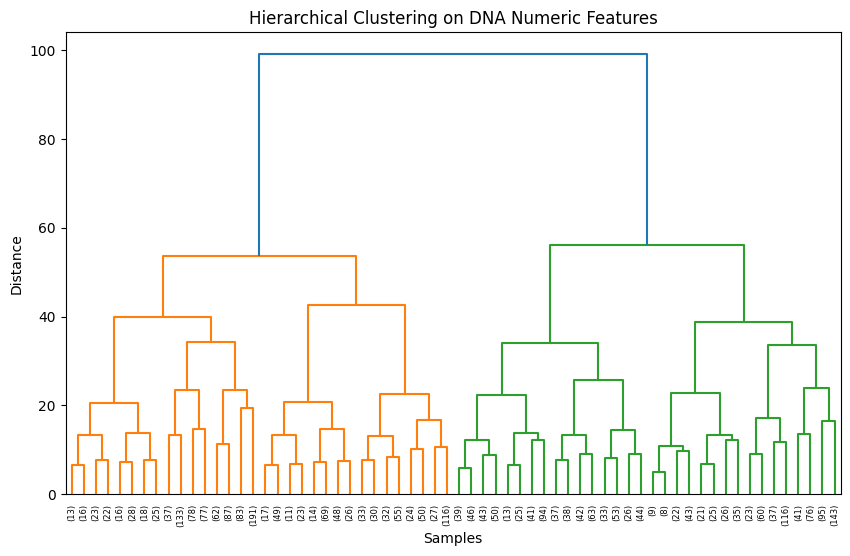

In [ ]:
# Perform hierarchical clustering using Ward's method (minimizes variance within clusters)
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(Z, truncate_mode='level', p=5)  # truncate_mode='level' shows only the top p levels for clarity
plt.title("Hierarchical Clustering on DNA Numeric Features")
plt.xlabel("DNA Samples")   # X-axis: individual samples or merged clusters
plt.ylabel("Distance")  # Y-axis: distance/dissimilarity at which clusters are merged
plt.show()


In [ ]:
# Choose a distance threshold or number of clusters
cluster_labels = fcluster(Z, t=5, criterion='distance')

# Add these cluster labels back to your sampled DataFrame
dna['Cluster'] = cluster_labels

comparison_table = pd.crosstab(dna['Cluster'], dna['Class_Label'])
print("Class Label")
print(comparison_table)

print("\nDisease Risk")
comparison_table_risk = pd.crosstab(dna['Cluster'], dna['Disease_Risk'])
print(comparison_table_risk)

Class Label
Class_Label  Bacteria  Human  Plant  Virus
Cluster                                   
1                   3      2      4      4
2                   4      1      5      6
3                   1      2      2      2
4                   5      3      0      8
5                   2      2      1      4
...               ...    ...    ...    ...
121                 2      4      4      5
122                 8      5      8      8
123                11      5      9      5
124                 4      8      9      8
125                12      9     11      8

[125 rows x 4 columns]

Disease Risk
Disease_Risk  High  Low  Medium
Cluster                        
1                3    4       6
2                5    7       4
3                0    3       4
4                3    7       6
5                3    3       3
...            ...  ...     ...
121              2    6       7
122              8    9      12
123             16    9       5
124              8   14       7
125    

Insights and Interpretation

It shows the each vertical line at the bottom represents a DNA sample. This clustering algorithm grouped the samples that are similar based on their numeric features first.

The height of the branches meanwhile reflects how different these groups are. A lower height means more similarity and a higher high means they are different.